In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = r"data/infosys/INFY.csv"
COMPANY_NAME = "Infosys"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,217.472549,326.575012,328.750000,324.412506,326.250000,4069264
1,2010-01-05,218.200928,327.668762,328.837494,325.012512,327.500000,6895528
2,2010-01-06,215.017029,322.887512,335.375000,321.887512,335.375000,6817288
3,2010-01-07,210.184906,315.631256,323.325012,314.774994,323.325012,10892600
4,2010-01-08,205.119812,308.024994,315.412506,307.250000,314.875000,12649312


General

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Shape: (4131, 7)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Date         datetime64[us]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Date range:
2010-01-04 00:00:00 to 2026-09-21 00:00:00


Trend

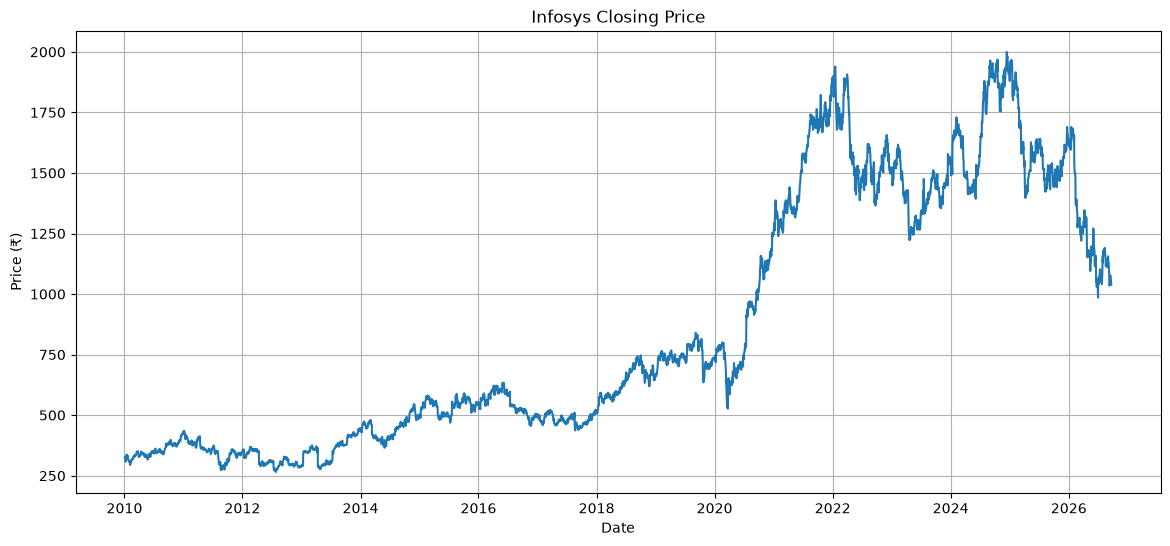

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title(f"{COMPANY_NAME} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

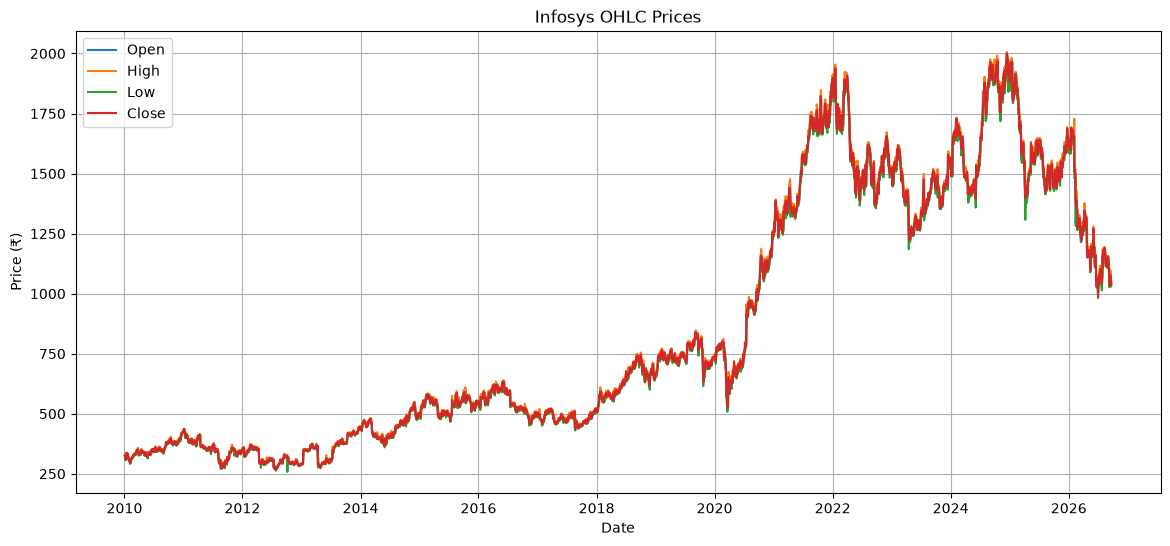

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title(f"{COMPANY_NAME} OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Volume

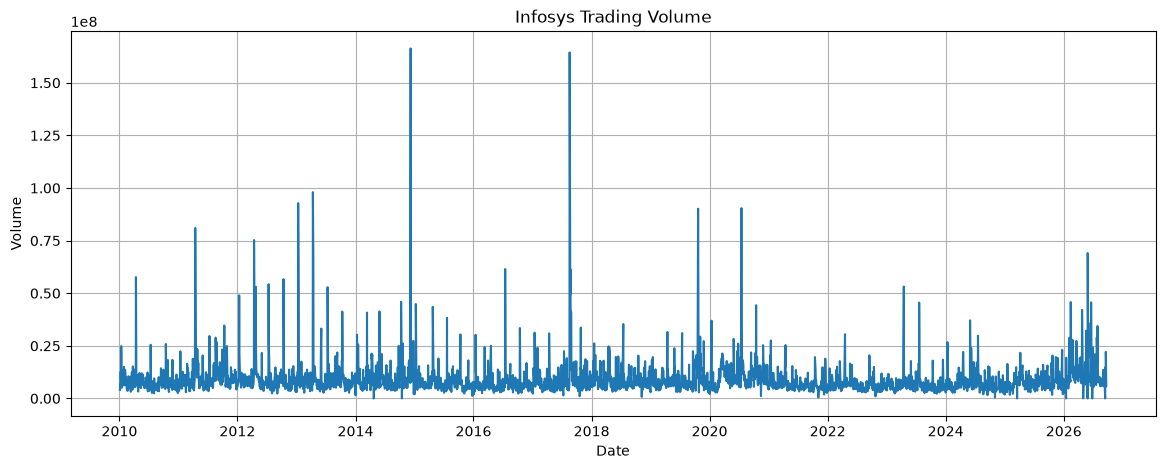

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volume"])

plt.title(f"{COMPANY_NAME} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [8]:
df["Volume"].describe()

count    4.131000e+03
mean     8.630188e+06
std      7.444685e+06
min      0.000000e+00
25%      5.267040e+06
50%      7.024178e+06
75%      9.700392e+06
max      1.663204e+08
Name: Volume, dtype: float64

Returns

In [9]:
df["Return"] = df["Close"].pct_change()

df[["Date", "Close", "Return"]].head(10)

,Date,Close,Return
0,2010-01-04,326.575012,NaN
1,2010-01-05,327.668762,0.003349
2,2010-01-06,322.887512,-0.014592
3,2010-01-07,315.631256,-0.022473
4,2010-01-08,308.024994,-0.024099
5,2010-01-11,311.206238,0.010328
6,2010-01-12,323.368744,0.039082
7,2010-01-13,335.437500,0.037322
8,2010-01-14,336.218750,0.002329
9,2010-01-15,334.475006,-0.005186


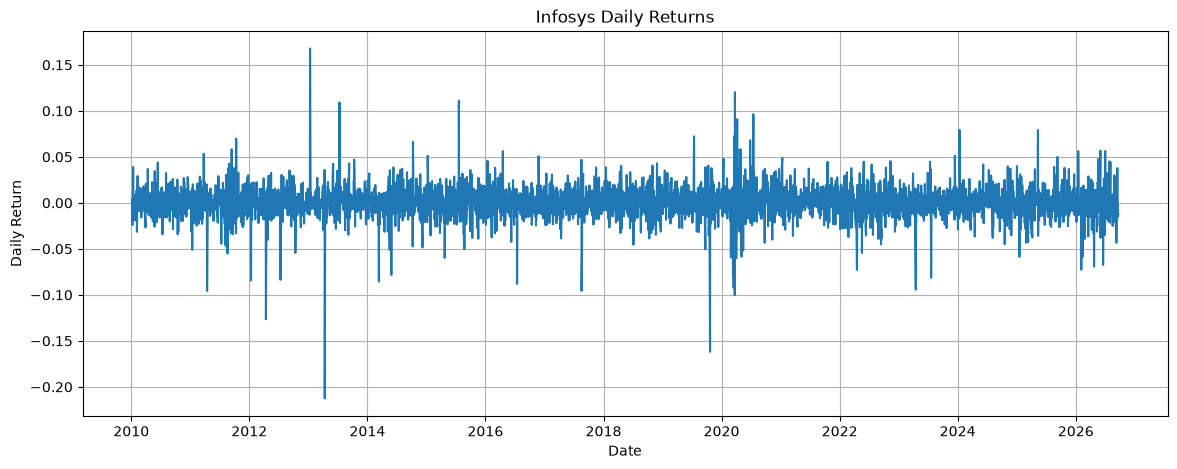

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Return"])

plt.title(f"{COMPANY_NAME} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [11]:
df["Return"].describe()

count    4130.000000
mean        0.000430
std         0.017228
min        -0.212586
25%        -0.008218
50%         0.000363
75%         0.009549
max         0.167851
Name: Return, dtype: float64

Annual Volatility

In [12]:
annual_volatility = df["Return"].std() * np.sqrt(252)

print(f"Annualized volatility: {annual_volatility:.2%}")

Annualized volatility: 27.35%


Simple Moving Averages

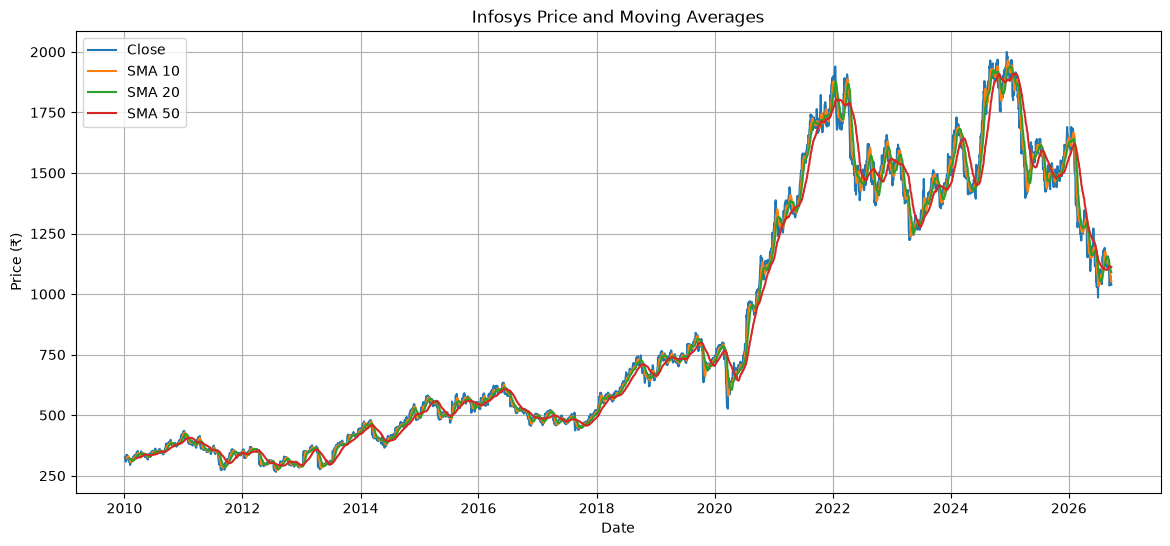

In [13]:
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_10"], label="SMA 10")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.title(f"{COMPANY_NAME} Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Exponential Moving Averages

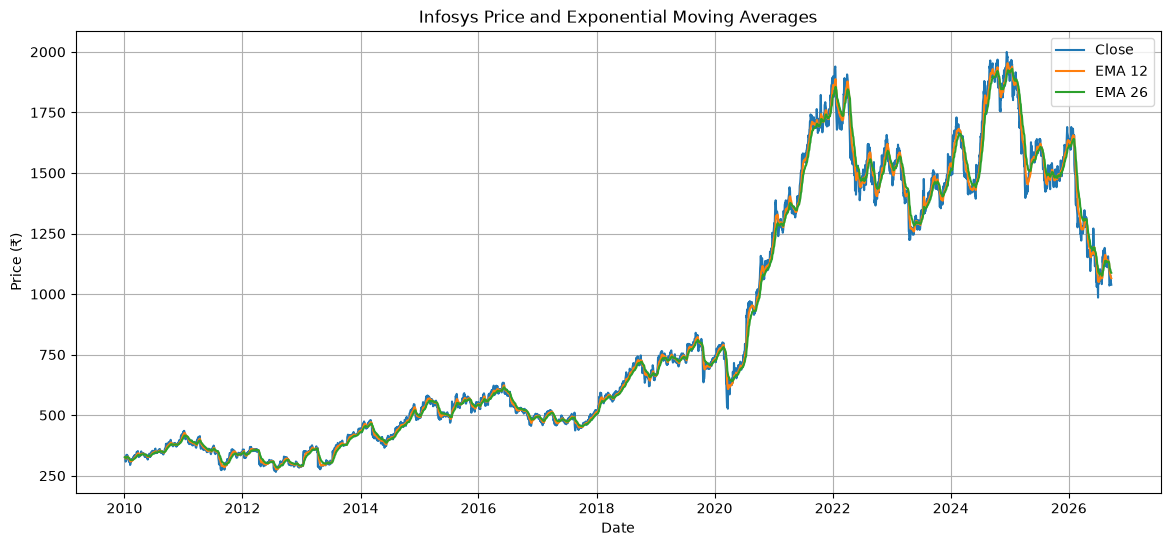

In [14]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_12"], label="EMA 12")
plt.plot(df["Date"], df["EMA_26"], label="EMA 26")

plt.title(f"{COMPANY_NAME} Price and Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Twenty Day Rolling Volitality

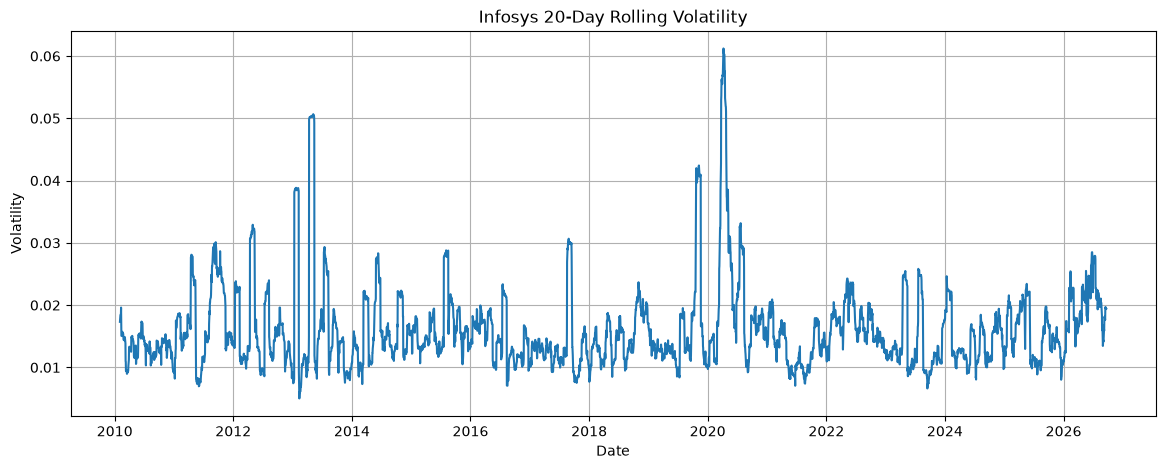

In [15]:
df["Volatility_20"] = df["Return"].rolling(20).std()

plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volatility_20"])

plt.title(f"{COMPANY_NAME} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

Correlation

In [16]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "EMA_12",
    "EMA_26",
    "Volatility_20",
]

df[features].corr()

,Open,High,Low,Close,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
Open,1.000000,0.999848,0.999848,0.999701,-0.121383,-0.012063,0.998820,0.997191,0.991905,0.998941,0.997207,-0.083612
High,0.999848,1.000000,0.999835,0.999885,-0.117652,-0.002883,0.998779,0.997186,0.992004,0.998922,0.997222,-0.081242
Low,0.999848,0.999835,1.000000,0.999877,-0.125812,-0.002463,0.998652,0.996983,0.991639,0.998790,0.997002,-0.085746
Close,0.999701,0.999885,0.999877,1.000000,-0.122114,0.004610,0.998598,0.996949,0.991673,0.998751,0.996981,-0.083739
Volume,-0.121383,-0.117652,-0.125812,-0.122114,1.000000,-0.095725,-0.116843,-0.114334,-0.110297,-0.117307,-0.114145,0.285600
Return,-0.012063,-0.002883,-0.002463,0.004610,-0.095725,1.000000,-0.018781,-0.021324,-0.020481,-0.017786,-0.019793,-0.004112
SMA_10,0.998820,0.998779,0.998652,0.998598,-0.116843,-0.018781,1.000000,0.999180,0.994462,0.999914,0.999003,-0.080825
SMA_20,0.997191,0.997186,0.996983,0.996949,-0.114334,-0.021324,0.999180,1.000000,0.996855,0.999442,0.999784,-0.074816
SMA_50,0.991905,0.992004,0.991639,0.991673,-0.110297,-0.020481,0.994462,0.996855,1.000000,0.995255,0.998015,-0.058759
EMA_12,0.998941,0.998922,0.998790,0.998751,-0.117307,-0.017786,0.999914,0.999442,0.995255,1.000000,0.999344,-0.079206


<Axes: >

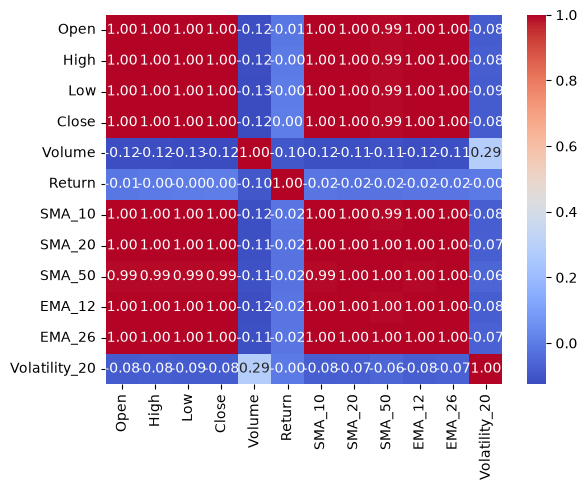

In [17]:
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

In [18]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
4126,2026-09-15,1077.000000,1077.000000,1097.699951,1071.699951,1085.000000,14816117,0.037872,1079.369995,1105.155005,1113.582000,1079.657039,1101.026219,0.019504
4127,2026-09-16,1060.000000,1060.000000,1085.099976,1053.500000,1082.500000,6230590,-0.015785,1071.369995,1102.165002,1113.395999,1076.632879,1097.987240,0.019702
4128,2026-09-17,1058.599976,1058.599976,1063.599976,1048.599976,1054.900024,5469865,-0.001321,1064.199988,1098.595001,1113.551997,1073.858586,1095.069664,0.019515
4129,2026-09-18,1051.400024,1051.400024,1061.900024,1038.000000,1061.900024,22124953,-0.006801,1056.339990,1095.115002,1113.219998,1070.403423,1091.834876,0.019501
4130,2026-09-21,1038.500000,1038.500000,1044.500000,1030.300049,1041.500000,6074358,-0.012269,1051.439990,1090.540002,1111.937998,1065.495204,1087.884145,0.019424


In [19]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,4131.0,8.613006e+02,5.199746e+02,270.000000,4.181875e+02,6.126000e+02,1.411625e+03,1.995450e+03
High,4131.0,8.698661e+02,5.245205e+02,270.500000,4.226062e+02,6.199000e+02,1.425025e+03,2.006450e+03
Low,4131.0,8.524169e+02,5.150238e+02,257.568756,4.147750e+02,6.031000e+02,1.397875e+03,1.977600e+03
Close,4131.0,8.610865e+02,5.197390e+02,265.475006,4.183156e+02,6.091500e+02,1.411150e+03,1.999700e+03
Volume,4131.0,8.630188e+06,7.444685e+06,0.000000,5.267040e+06,7.024178e+06,9.700392e+06,1.663204e+08
Return,4130.0,4.298130e-04,1.722796e-02,-0.212586,-8.218461e-03,3.628810e-04,9.548761e-03,1.678509e-01
SMA_10,4122.0,8.614682e+02,5.195383e+02,272.301874,4.179236e+02,6.081988e+02,1.410970e+03,1.963785e+03
SMA_20,4112.0,8.618467e+02,5.193491e+02,275.634375,4.190820e+02,6.103087e+02,1.423484e+03,1.940243e+03
SMA_50,4082.0,8.628684e+02,5.185923e+02,291.133500,4.229515e+02,6.067817e+02,1.441070e+03,1.909986e+03
EMA_12,4131.0,8.601027e+02,5.192825e+02,276.675037,4.172144e+02,6.074545e+02,1.414683e+03,1.953467e+03


The correlation analysis indicates strong multicollinearity among OHLC and moving-average-based features. However, these features capture different aspects of price and trend information. To maintain a compact observation space while retaining market, trend, momentum, and volatility information, the final RL state will use Close, Volume, Return, SMA-20, SMA-50, EMA-12, EMA-26, and 20-day volatility. Feature scaling and relative transformations will be performed using the training data during model development.